# 03 · Finding and driving the qubit

Part 2 found the readout resonator. That tells you where to point the readout tone, and nothing
about the qubit. A transmon sitting at 4.85 GHz is invisible in a 7.2 GHz transmission scan.

This part closes that gap and then calibrates a gate:

1. **Two-tone spectroscopy** finds `f01` by driving the qubit with a second tone while watching the
   resonator.
2. **Rabi in amplitude** turns `f01` into a pi pulse: the amplitude that flips the qubit.
3. The **calibration seam**: a program that names its pulses, and a library that supplies the
   numbers.
4. The **flux arc**: a 2D map of `f01` against a DC flux bias, and the first experiment in this
   tutorial whose outer loop cannot run on a sequencer.

Every fit in this notebook prints the fitted value next to the true one, because the device is
simulated and you can check your own work.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.waveforms import IQDrag, IQPair, Square

print("numpy", np.__version__, "| scipy", scipy.__version__, "(curve_fit does every fit below)")

numpy 2.5.2 | scipy 1.18.1 (curve_fit does every fit below)


## 3.0 The device under test

`DEVICE` holds the truth about the simulated chip. The measurement models read it, because they
play the part of the fridge, and the print statements read it to grade the fits. The programs use
exactly one number from it, `q0_fr`, and only because Part 2 measured that one already. Everything
else they have to find out. A real experiment does not know these numbers, so neither does the code
that would run on hardware.

Part 2 also left two waveforms behind: the readout pulse and the integration weights. The programs
below ask for them by name, as the strings `"readout"` and `"weights"`, and the library in 3.3 is
where the objects go.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, qubit transition at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator (found in Part 2)
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,  # Hz, dispersive shift
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "flux_period": 1.0,  # V, one flux quantum in bias volts
    "flux_offset": 0.05,  # V, where the sweet spot actually sits
}

schema = BusSchema.transmon()
q = schema.q

READOUT_PULSE = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
WEIGHTS = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

print("drive bus  :", q[0].drive, "channel:", q[0].drive.channel)
print("readout bus:", q[0].readout, "acquires:", q[0].readout.acquires)
print("readout pulse:", READOUT_PULSE.get_duration(), "ns")
print("target to recover: f01 =", DEVICE["q0_f01"] / 1e9, "GHz")

drive bus  : q0/drive channel: IQ
readout bus: q0/readout acquires: True
readout pulse: 2000 ns
target to recover: f01 = 4.85 GHz


## 3.1 Two-tone spectroscopy

The resonator is coupled to the qubit, so the qubit's state pulls the resonator frequency by the
dispersive shift $\chi$. Dispersive readout is built on that pull, and so is finding the qubit in
the first place:

1. Park the readout tone at the resonator, where Part 2 put it.
2. Send a second tone down the **drive** line and sweep its frequency.
3. When the second tone hits `f01` the qubit gets excited, the resonator moves, and the readout
   changes.

The drive pulse for this scan is long and weak: 4 microseconds at 2% of full scale. You do not yet
know the amplitude of a pi pulse, so you cannot ask for a clean flip. Instead you saturate the
transition and settle at a population somewhere below 0.5, the value the model below returns.

The window is 20 MHz wide, so this scan assumes you already know `f01` to roughly that much, from
the chip design, from a cooldown last month, or from a wide survey scan like the flux arc in 3.4.
Drive a survey scan hard and the line broadens, which keeps the peak findable on a coarse grid.
This tone is weak, so the line stays near its 2 MHz low-power width and the 250 kHz step puts eight
points across it.

The drive bus is an IQ channel, so the saturation tone is an `IQPair`. A bare `Square` on that bus
raises a `ValidationError` at build time.

In [4]:
SATURATION = IQPair(
    I=Square(amplitude=0.02, duration=4000),  # 4 us at 2% of full scale
    Q=Square(amplitude=0.0, duration=4000),
)


def p_spec(bus, env):
    """Excited-state population under a long weak drive: a Lorentzian peak at f01."""
    hwhm = DEVICE["q0_linewidth"] / 2
    return 0.45 / (1.0 + ((env["drive_freq"] - DEVICE["q0_f01"]) / hwhm) ** 2)


print("on resonance :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"]}), 4))
print("2 MHz off    :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"] + 2e6}), 4))
print("20 MHz off   :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"] + 20e6}), 4))

on resonance : 0.45
2 MHz off    : 0.09
20 MHz off   : 0.0011


### Asking for the state field

Part 2 read `iq`, the integrated readout point, because a resonator scan is about transmission. Here
the quantity of interest is the qubit population, so the measurement asks for a different field:

```python
program.measure(bus, "readout", "weights", fields=(MF.STATE,))
```

`fields=` is a request to the platform: produce classified single-shot outcomes for this
measurement, not just the integrated point. Three things follow from it.

- `average(shots)` adds no dimension. Averaging 200 single-shot zeros and ones gives you the
  excited-state population directly, as a float between 0 and 1.
- You read it back with `result.get(handle, field=MF.STATE)`. A bare `result.get(handle)` defaults
  to `iq` and raises `KeyError` here, because this measurement never asked for `iq`.
- On real hardware the classifier needs its own calibration (Part 4 does that with single shots).
  In the simulator the `p_excited` callback of `MockMeasurementModel` supplies the probability and
  the model draws the shots.

In [5]:
spec = qp.QProgram(
    label="qubit_spectroscopy",
    description="Two-tone scan for f01 on q0",
    schema=schema,
)
drive_freq = spec.variable("drive_freq", label="Drive frequency", units="Hz")

# 81 points x 200 shots = 16k interpreted shots, well under a second.
with spec.average(shots=200):
    with spec.sweep(drive_freq, qp.Linspace(4.840e9, 4.860e9, 81)):
        spec.set_frequency(q[0].readout, DEVICE["q0_fr"])  # park the readout on the resonator
        spec.set_frequency(q[0].drive, drive_freq)  # the tone we are sweeping
        spec.play(q[0].drive, SATURATION)
        spec.sync()  # on hardware, hold the readout until the drive finishes
        m_spec = spec.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print("variables :", [v.id for v in spec.variables])
print("handle    :", m_spec.name)
print("sweep step:", (4.860e9 - 4.840e9) / 80 / 1e6, "MHz")
print()
print(qp.dumps(spec))

variables : ['drive_freq']
handle    : q0/readout/m0
sweep step: 0.25 MHz

#!QProgram 1.0

metadata:
  label: "qubit_spectroscopy"
  description: "Two-tone scan for f01 on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var drive_freq label="Drive frequency" units="Hz"

  average 200:
    for drive_freq in Linspace(start=4840000000.0, stop=4860000000.0, num=81):
      set_frequency q[0].readout 7200000000.0
      set_frequency q[0].drive drive_freq
      play q[0].drive IQPair(I=Square(amplitude=0.02, duration=4000), Q=Square(amplitude=0.0, duration=4000))
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



Two details in that text worth a second look. The readout pulse and weights are still the strings
`"readout"` and `"weights"`, because nothing in this experiment depends on their shape. And
`fields=["state"]` is on the measure line, so the file records what the experiment asked the
hardware to produce.

dims: ('drive_freq',) shape: (81,)


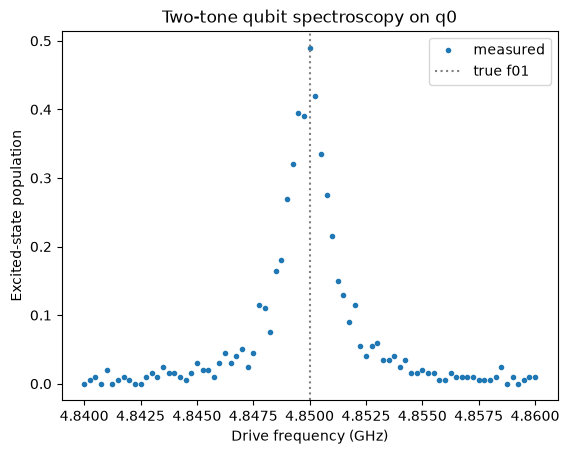

In [6]:
model = qp.MockMeasurementModel(p_excited=p_spec, noise=0.02, seed=11)
result = qp.simulate(spec, model=model)

pop = result.get(m_spec, field=MF.STATE)
print("dims:", pop.dims, "shape:", pop.shape)

spec_freqs = pop.coords["drive_freq"].values
spec_pop = pop.values

plt.plot(spec_freqs / 1e9, spec_pop, ".", label="measured")
plt.axvline(DEVICE["q0_f01"] / 1e9, color="grey", linestyle=":", label="true f01")
plt.xlabel("Drive frequency (GHz)")
plt.ylabel("Excited-state population")
plt.title("Two-tone qubit spectroscopy on q0")
plt.legend()
plt.show()

### Fitting the peak

The highest point in the scan is a poor estimate of `f01`: it can only ever be as accurate as your
step size, and with 250 kHz steps and shot noise on every point it will land on the wrong grid point
often enough to matter. A fit uses all 81 points and gives you an uncertainty for free.

The peak is a Lorentzian:

$$P(f) = P_0 + \frac{A}{1 + \left(\dfrac{f - f_{01}}{\gamma}\right)^2}$$

with $\gamma$ the half width at half maximum, so the linewidth you would quote in a paper is
$2\gamma$. Four free parameters, and `curve_fit` wants a starting guess for each. Read them off the
data: the peak position from `argmax`, the height from the range, the width from your prior (a few
megahertz), and the floor from the median.

In [7]:
def lorentzian(f, f0, height, hwhm, floor):
    """Lorentzian peak, parameterised the way a spectroscopist reads it off a plot."""
    return floor + height / (1.0 + ((f - f0) / hwhm) ** 2)


guess = (
    spec_freqs[spec_pop.argmax()],  # centre
    spec_pop.max() - np.median(spec_pop),  # height
    1e6,  # HWHM, order of magnitude is enough
    float(np.median(spec_pop)),  # floor
)
spec_fit, spec_cov = curve_fit(lorentzian, spec_freqs, spec_pop, p0=guess)
f01_fit, height_fit, hwhm_fit, floor_fit = spec_fit
f01_sigma = float(np.sqrt(np.diag(spec_cov))[0])

print(f"argmax    : {spec_freqs[spec_pop.argmax()] / 1e9:.6f} GHz  (grid step 0.250 MHz)")
print(f"fitted    : {f01_fit / 1e9:.6f} GHz  +/- {f01_sigma / 1e6:.3f} MHz")
print(f"true      : {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"error     : {(f01_fit - DEVICE['q0_f01']) / 1e6:+.3f} MHz")
print(f"linewidth : {2 * abs(hwhm_fit) / 1e6:.3f} MHz fitted vs {DEVICE['q0_linewidth'] / 1e6:.3f} MHz true")

argmax    : 4.850000 GHz  (grid step 0.250 MHz)
fitted    : 4.849928 GHz  +/- 0.017 MHz
true      : 4.850000 GHz
error     : -0.072 MHz
linewidth : 1.983 MHz fitted vs 2.000 MHz true


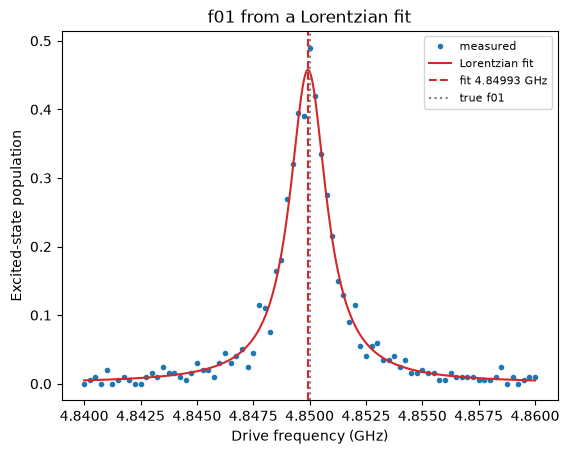

In [8]:
dense = np.linspace(spec_freqs[0], spec_freqs[-1], 800)

plt.plot(spec_freqs / 1e9, spec_pop, ".", color="tab:blue", label="measured")
plt.plot(dense / 1e9, lorentzian(dense, *spec_fit), color="tab:red", label="Lorentzian fit")
plt.axvline(f01_fit / 1e9, color="tab:red", linestyle="--", label=f"fit {f01_fit / 1e9:.5f} GHz")
plt.axvline(DEVICE["q0_f01"] / 1e9, color="grey", linestyle=":", label="true f01")
plt.xlabel("Drive frequency (GHz)")
plt.ylabel("Excited-state population")
plt.title("f01 from a Lorentzian fit")
plt.legend(fontsize=8)
plt.show()

## 3.2 Rabi: how hard to hit it

You now know where the qubit is. The next question is how much amplitude a 40 ns pulse needs to
rotate the state by $\pi$. Drive on resonance, sweep the amplitude, measure the population. The
population follows $\sin^2$ of the rotation angle, and the first maximum is the pi pulse.

Two things in the program are new.

The pulse is an `IQDrag`, the standard single-qubit envelope on a transmon. A Gaussian on I and its
scaled derivative on Q, which suppresses leakage to the second excited state. Part 1 plotted it.

The swept variable goes **inside the waveform**:

```python
program.play(q[0].drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))
```

`amp` is a `Variable`, not a number. Every waveform parameter accepts an `Expression`, so the pulse
is parametric and the loop binds it. The `.qp` text keeps the variable name, which means the file
records the sweep rather than 41 hard-coded pulses.

In [9]:
def p_rabi(bus, env):
    """Rabi oscillation in amplitude: a full pi rotation at DEVICE['q0_a_pi']."""
    return np.sin(np.pi * env["amp"] / (2 * DEVICE["q0_a_pi"])) ** 2


rabi = qp.QProgram(label="rabi_amplitude", description="Amplitude Rabi on q0", schema=schema)
amp = rabi.variable("amp", label="Drive amplitude", units="V")

with rabi.average(shots=200):
    with rabi.sweep(amp, qp.Linspace(0.0, 1.0, 41)):
        rabi.set_frequency(q[0].drive, f01_fit)  # the fitted frequency, not the true one
        rabi.play(q[0].drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))
        rabi.sync()
        m_rabi = rabi.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(rabi))

#!QProgram 1.0

metadata:
  label: "rabi_amplitude"
  description: "Amplitude Rabi on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var amp label="Drive amplitude" units="V"

  average 200:
    for amp in Linspace(start=0.0, stop=1.0, num=41):
      set_frequency q[0].drive 4849928431.82247
      play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



dims: ('amp',) shape: (41,)
highest measured point at amplitude 0.575
(a noisy estimate of the pi amplitude; the fit below uses every point)


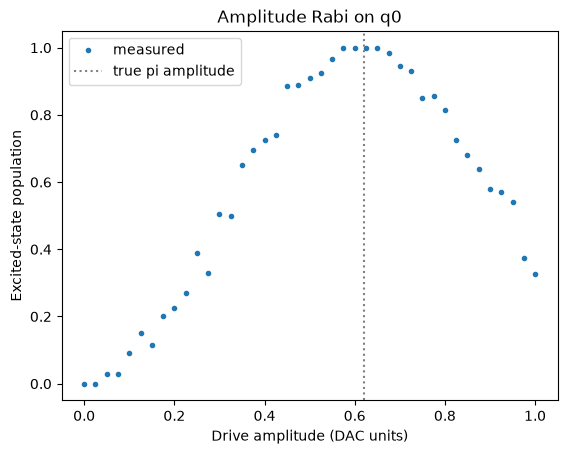

In [10]:
rabi_result = qp.simulate(rabi, model=qp.MockMeasurementModel(p_excited=p_rabi, noise=0.02, seed=17))
rabi_data = rabi_result.get(m_rabi, field=MF.STATE)

rabi_amps = rabi_data.coords["amp"].values
rabi_pop = rabi_data.values
print("dims:", rabi_data.dims, "shape:", rabi_data.shape)
print("highest measured point at amplitude", round(float(rabi_amps[rabi_pop.argmax()]), 4))
print("(a noisy estimate of the pi amplitude; the fit below uses every point)")

plt.plot(rabi_amps, rabi_pop, ".", label="measured")
plt.axvline(DEVICE["q0_a_pi"], color="grey", linestyle=":", label="true pi amplitude")
plt.xlabel("Drive amplitude (DAC units)")
plt.ylabel("Excited-state population")
plt.title("Amplitude Rabi on q0")
plt.legend()
plt.show()

### Fitting the pi amplitude

The curve is

$$P(a) = P_0 + C \sin^2\!\left(\frac{\pi a}{2 a_\pi}\right)$$

so $a_\pi$ is the amplitude at the first maximum. Fitting for it directly, rather than fitting a
generic sinusoid and converting afterwards, means `curve_fit` reports the uncertainty on the number
you actually want. Do that deliberately every time. Write the model in terms of the calibration
parameter.

$C$ is the readout contrast and $P_0$ the floor. On a real device neither is 1 and 0, and watching
them drift is one of the cheapest health checks you have.

In [11]:
def rabi_model(a, a_pi, contrast, floor):
    """Rabi in amplitude, parameterised by the pi amplitude itself."""
    return floor + contrast * np.sin(np.pi * a / (2 * a_pi)) ** 2


rabi_fit, rabi_cov = curve_fit(
    rabi_model,
    rabi_amps,
    rabi_pop,
    p0=(rabi_amps[rabi_pop.argmax()], rabi_pop.max() - rabi_pop.min(), rabi_pop.min()),
)
a_pi_fit, contrast_fit, floor_fit = rabi_fit
a_pi_sigma = float(np.sqrt(np.diag(rabi_cov))[0])

print(f"a_pi fitted : {a_pi_fit:.4f} +/- {a_pi_sigma:.4f}")
print(f"a_pi true   : {DEVICE['q0_a_pi']:.4f}")
print(f"error       : {100 * (a_pi_fit - DEVICE['q0_a_pi']) / DEVICE['q0_a_pi']:+.2f}%")
print(f"contrast    : {contrast_fit:.3f}   floor: {floor_fit:.3f}")

a_pi fitted : 0.6212 +/- 0.0028
a_pi true   : 0.6200
error       : +0.19%
contrast    : 0.990   floor: 0.009


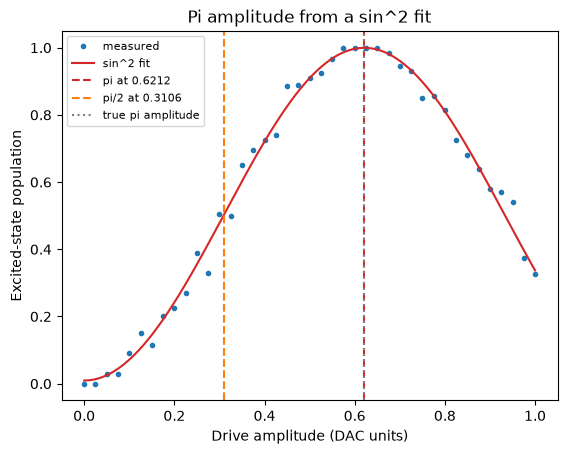

In [12]:
dense_amp = np.linspace(rabi_amps[0], rabi_amps[-1], 400)

plt.plot(rabi_amps, rabi_pop, ".", color="tab:blue", label="measured")
plt.plot(dense_amp, rabi_model(dense_amp, *rabi_fit), color="tab:red", label="sin^2 fit")
plt.axvline(a_pi_fit, color="tab:red", linestyle="--", label=f"pi at {a_pi_fit:.4f}")
plt.axvline(a_pi_fit / 2, color="tab:orange", linestyle="--", label=f"pi/2 at {a_pi_fit / 2:.4f}")
plt.axvline(DEVICE["q0_a_pi"], color="grey", linestyle=":", label="true pi amplitude")
plt.xlabel("Drive amplitude (DAC units)")
plt.ylabel("Excited-state population")
plt.title("Pi amplitude from a sin^2 fit")
plt.legend(fontsize=8)
plt.show()

### The calibrated pulses

A calibrated gate, in this stack, is a waveform object with numbers in it. Nothing more.

`PI_PULSE` flips the qubit. `X90_PULSE` takes it to the equator and is the workhorse of Part 4:
Ramsey needs two of them, and the echo needs two with a pi pulse in between. Both are plain
`IQDrag` instances, so they compare by structure. Two pulses are equal when every parameter
matches. A calibration set is diffable for that reason, and it is why an amplitude gets rounded
before it goes in a file. The fit above knows this amplitude to about 0.003, so four decimals is
already finer than the measurement, and it keeps the text readable.

Halving `a_pi` for the x90 assumes the response is exactly $\sin^2$. Exercise 3.1 checks it.

pi  : 0.6212 over 40 ns
x90 : 0.3106 over 40 ns
structural equality: True
a different beta is a different pulse: False


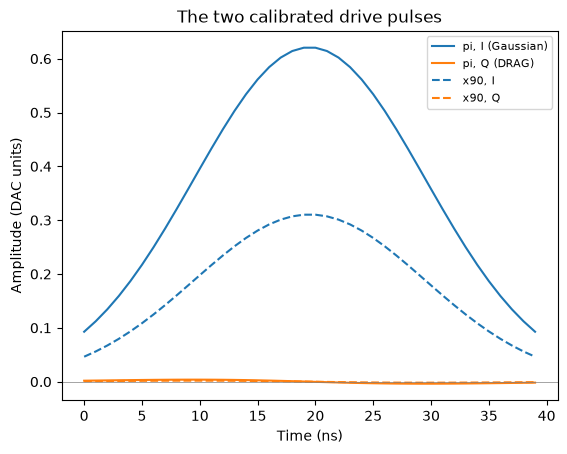

In [13]:
PI_PULSE = IQDrag(amplitude=round(float(a_pi_fit), 4), duration=40, sigma=10, beta=0.1)
X90_PULSE = IQDrag(amplitude=round(float(a_pi_fit) / 2, 4), duration=40, sigma=10, beta=0.1)

print("pi  :", PI_PULSE.amplitude, "over", PI_PULSE.get_duration(), "ns")
print("x90 :", X90_PULSE.amplitude, "over", X90_PULSE.get_duration(), "ns")
print("structural equality:", PI_PULSE == IQDrag(PI_PULSE.amplitude, 40, 10, 0.1))
print("a different beta is a different pulse:", PI_PULSE == IQDrag(PI_PULSE.amplitude, 40, 10, 0.2))

t_ns = np.arange(PI_PULSE.get_duration())

plt.plot(t_ns, PI_PULSE.get_I().envelope(), color="tab:blue", label="pi, I (Gaussian)")
plt.plot(t_ns, PI_PULSE.get_Q().envelope(), color="tab:orange", label="pi, Q (DRAG)")
plt.plot(t_ns, X90_PULSE.get_I().envelope(), "--", color="tab:blue", label="x90, I")
plt.plot(t_ns, X90_PULSE.get_Q().envelope(), "--", color="tab:orange", label="x90, Q")
plt.axhline(0.0, color="grey", linewidth=0.5)
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (DAC units)")
plt.title("The two calibrated drive pulses")
plt.legend(fontsize=8)
plt.show()

### 🧩 Exercise 3.1: fit the x90 amplitude instead of halving

Rather than trusting $a_\pi / 2$, measure it. Refit **only the rising branch** of the Rabi curve
(everything up to the maximum) with the model written in terms of $a_{90}$:

$$P(a) = P_0 + C \sin^2\!\left(\frac{\pi a}{4 a_{90}}\right)$$

At $a = a_{90}$ the sine argument is $\pi/4$ and the population is halfway up, which is exactly the
definition of a $\pi/2$ rotation.

Print the fitted $a_{90}$, the halved $a_\pi$ from the full fit, and the true $a_\pi / 2$ from
`DEVICE`. You have `rabi_amps`, `rabi_pop`, `a_pi_fit`, `contrast_fit`, and `floor_fit` in scope.

In [14]:
rising = slice(0, int(rabi_pop.argmax()) + 1)  # up to and including the maximum


def x90_model(a, a_90, contrast, floor):
    """The same physics as rabi_model, parameterised by the pi/2 amplitude."""
    return floor + contrast * np.sin(np.pi * a / (4 * a_90)) ** 2


x90_fit, x90_cov = curve_fit(
    x90_model,
    rabi_amps[rising],
    rabi_pop[rising],
    p0=(a_pi_fit / 2, contrast_fit, floor_fit),
)
a_90_fit = float(x90_fit[0])
a_90_true = DEVICE["q0_a_pi"] / 2

print(f"points used   : {len(rabi_amps[rising])} of {len(rabi_amps)}")
print(f"a_90 fitted   : {a_90_fit:.4f} +/- {float(np.sqrt(np.diag(x90_cov))[0]):.4f}")
print(f"a_pi_fit / 2  : {a_pi_fit / 2:.4f}")
print(f"true a_pi / 2 : {a_90_true:.4f}")
print(f"error vs true : {100 * (a_90_fit - a_90_true) / a_90_true:+.2f}%")

points used   : 24 of 41
a_90 fitted   : 0.3105 +/- 0.0102
a_pi_fit / 2  : 0.3106
true a_pi / 2 : 0.3100
error vs true : +0.15%


## 3.3 The calibration seam

Look at what just happened to the experiment code. The Rabi program has `IQDrag(amplitude=amp, ...)`
baked into it, and that was right: the pulse shape *is* the experiment. But every program that comes
after it wants "the pi pulse", whatever today's number happens to be. If each one inlines 0.6212,
then recalibrating means editing every file, and a file from six months ago silently claims a
calibration it never had.

QProgram splits the two. Where a waveform is expected you may write a **string alias**, and the
program is then a statement about structure with a hole in it:

```python
program.play(q[0].drive, "pi")
```

The alias survives serialization, so the `.qp` file says `play q[0].drive "pi"`. Filling the hole is
a separate step, `program.with_waveforms(...)`, which returns a new program with the names resolved.
The original is untouched.

The reference platform never looks at a waveform, so an unbound alias costs nothing there. Every
`measure` in this notebook can name `"readout"` and `"weights"` and still run because of it. A real
platform has to turn the name into samples, so off the simulator the binding step is not optional.

In [15]:
seq = qp.QProgram(label="pi_then_read", description="Flip q0 and read it out", schema=schema)

with seq.average(shots=200):
    seq.play(q[0].drive, "pi")
    seq.sync()
    m_seq = seq.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(seq))

#!QProgram 1.0

metadata:
  label: "pi_then_read"
  description: "Flip q0 and read it out"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  average 200:
    play q[0].drive "pi"
    sync
    measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



A `WaveformLibrary` is where the numbers live. It resolves a name **per bus**, in three tiers:

| Tier | How you register it | Matches |
|---|---|---|
| exact | `element=`, `idx=`, `kind=` | one bus |
| family | `element=`, `kind=` | every index of that element and kind |
| global | no keywords | every bus |

Drive pulses belong in the exact tier, because `q[0]` and `q[1]` do not share a pi amplitude.
Readout pulses are often a family default. Integration weights are frequently global. Part 5 goes
through the resolution order properly; here it is enough to see the same alias land differently on
different buses.

In [16]:
library = qp.WaveformLibrary()
library.set("pi", PI_PULSE, element="q", idx=0, kind="drive")  # exact: this qubit only
library.set("x90", X90_PULSE, element="q", idx=0, kind="drive")
library.set("readout", READOUT_PULSE, element="q", kind="readout")  # family: any q readout
library.set("weights", WEIGHTS)  # global

bound = seq.with_waveforms(library)

print(qp.dumps(bound))
print("bound body differs from the original:", seq.body != bound.body)

#!QProgram 1.0

metadata:
  label: "pi_then_read"
  description: "Flip q0 and read it out"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  average 200:
    play q[0].drive IQDrag(amplitude=0.6212, duration=40, sigma=10, beta=0.1)
    sync
    measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state"]

bound body differs from the original: True


Binding costs you something, and the output above shows it plainly: the `measure` line now carries
two full `IQPair` constructors. That is the trade. An aliased file is short and reviewable but means
nothing without its library; a bound file is self-contained but unreadable and out of date the
moment you recalibrate.

The library has its own text format, `.wfl`, and it stays outside the `.qp` file on purpose.
The program is the experiment you designed. The library is the state of the fridge this morning.
Those two things change on completely different schedules, and a lab that keeps them in one file
ends up unable to answer "was this the same experiment?" across a recalibration.

In [17]:
print(library.dumps())

stale = qp.WaveformLibrary()
stale.set("pi", IQDrag(amplitude=0.50, duration=40, sigma=10, beta=0.1), element="q", idx=0, kind="drive")


def play_line(program):
    """Pull the single `play` statement out of a program's .qp text."""
    return next(line.strip() for line in qp.dumps(program).splitlines() if line.strip().startswith("play"))


print("bound to last week's library:", play_line(seq.with_waveforms(stale)))
print("bound to today's library    :", play_line(bound))
print("the program on disk         :", play_line(seq))

#!WaveformLibrary 1.0
"pi" q[0].drive = IQDrag(amplitude=0.6212, duration=40, sigma=10, beta=0.1)
"x90" q[0].drive = IQDrag(amplitude=0.3106, duration=40, sigma=10, beta=0.1)
"readout" q[*].readout = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
"weights" = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

bound to last week's library: play q[0].drive IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
bound to today's library    : play q[0].drive IQDrag(amplitude=0.6212, duration=40, sigma=10, beta=0.1)
the program on disk         : play q[0].drive "pi"


## 3.4 The flux arc

A flux-tunable transmon has a third line: a DC bias that threads flux through its loop and moves
`f01`. The frequency follows

$$f_{01}(V) = f_{\max} \sqrt{\left| \cos \frac{\pi (V - V_0)}{V_\Phi} \right|}$$

with $V_0$ the bias where the loop sees zero flux (the **sweet spot**, where $f_{01}$ is flattest
against bias noise) and $V_\Phi$ the bias interval that threads one flux quantum. You want $V_0$,
and you find it by repeating the spectroscopy of 3.1 at a series of biases. The scan is two
dimensional. Bias on the outer loop, drive frequency on the inner one.

Two changes to the program.

`BusSchema.flux_tunable_transmon()` adds `q[i].flux`, a **single**-channel bus with no ADC. Single
channel means single-channel waveforms: `Square`, not `IQPair`. Try it the other way and the builder
raises before you get near an instrument.

`set_offset(bus, value)` writes a DC level rather than playing a pulse. A bias line wants exactly
that. The value is the swept variable, so the outer loop is a sequence of DC writes.

In [18]:
flux_schema = BusSchema.flux_tunable_transmon()
qf = flux_schema.q

print("flux bus:", qf[0].flux, "channel:", qf[0].flux.channel, "acquires:", qf[0].flux.acquires)


def f01_of_bias(bias):
    """Where the qubit sits at a given flux bias. Maximum at DEVICE['flux_offset']."""
    phase = np.pi * (bias - DEVICE["flux_offset"]) / DEVICE["flux_period"]
    return DEVICE["q0_f01"] * np.sqrt(np.abs(np.cos(phase)))


POWER_BROADENED = 20e6  # Hz FWHM: this scan drives hard, so the line is much wider than 2 MHz


def p_arc(bus, env):
    """Spectroscopy peak that follows the arc as the bias steps."""
    hwhm = POWER_BROADENED / 2
    return 0.45 / (1.0 + ((env["arc_freq"] - f01_of_bias(env["bias"])) / hwhm) ** 2)


for bias_v in (-0.15, 0.05, 0.25):
    print(f"bias {bias_v:+.2f} V -> f01 {f01_of_bias(bias_v) / 1e9:.4f} GHz")

flux bus: q0/flux channel: single acquires: False
bias -0.15 V -> f01 4.3624 GHz
bias +0.05 V -> f01 4.8500 GHz
bias +0.25 V -> f01 4.3624 GHz


On the frequency grid: 25 bias points times 61 frequency points times 50 shots is 76k interpreted
shots, a little over a second. The frequency step is about 10 MHz, which would step straight over a
2 MHz line. That is why the model uses a 20 MHz power-broadened width, and it is not a cheat: a flux
arc is a survey scan, you drive it hard on purpose to keep the peak findable on a coarse grid, and
you go back to a narrow low-power scan once you know where to look.

Shots drop from 200 to 50 to pay for the second axis. A 2D map has to show you a ridge, not
measure a population to three digits.

In [19]:
arc = qp.QProgram(label="flux_arc", description="f01 against flux bias on q0", schema=flux_schema)
bias = arc.variable("bias", label="Flux bias", units="V")
arc_freq = arc.variable("arc_freq", label="Drive frequency", units="Hz")

with arc.average(shots=50):
    with arc.sweep(bias, qp.Linspace(-0.15, 0.25, 25)):
        arc.set_offset(qf[0].flux, bias)  # a DC write, not a pulse
        with arc.sweep(arc_freq, qp.Linspace(4.30e9, 4.90e9, 61)):
            arc.set_frequency(qf[0].drive, arc_freq)
            arc.play(qf[0].drive, SATURATION)
            arc.sync()
            m_arc = arc.measure(qf[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(arc))

#!QProgram 1.0

metadata:
  label: "flux_arc"
  description: "f01 against flux bias on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var bias label="Flux bias" units="V"
  var arc_freq label="Drive frequency" units="Hz"

  average 50:
    for bias in Linspace(start=-0.15, stop=0.25, num=25):
      set_offset q[0].flux bias
      for arc_freq in Linspace(start=4300000000.0, stop=4900000000.0, num=61):
        set_frequency q[0].drive arc_freq
        play q[0].drive IQPair(I=Square(amplitude=0.02, duration=4000), Q=Square(amplitude=0.0, duration=4000))
        sync
        measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



In [20]:
arc_result = qp.simulate(arc, model=qp.MockMeasurementModel(p_excited=p_arc, noise=0.02, seed=23))
arc_data = arc_result.get(m_arc, field=MF.STATE)

biases = arc_data.coords["bias"].values
arc_freqs = arc_data.coords["arc_freq"].values
arc_grid = arc_data.values
ridge = arc_freqs[arc_grid.argmax(axis=1)]  # brightest frequency at each bias

print("dims:", arc_data.dims, "shape:", arc_data.shape)
print("bias step:", round(float(biases[1] - biases[0]), 4), "V")
print("frequency step:", round(float(arc_freqs[1] - arc_freqs[0]) / 1e6, 2), "MHz")
print("ridge (GHz):", np.round(ridge / 1e9, 3))

dims: ('bias', 'arc_freq') shape: (25, 61)
bias step: 0.0167 V
frequency step: 10.0 MHz
ridge (GHz): [4.36 4.44 4.51 4.58 4.64 4.68 4.73 4.76 4.79 4.82 4.83 4.85 4.85 4.85
 4.83 4.82 4.8  4.77 4.73 4.69 4.63 4.58 4.51 4.44 4.36]


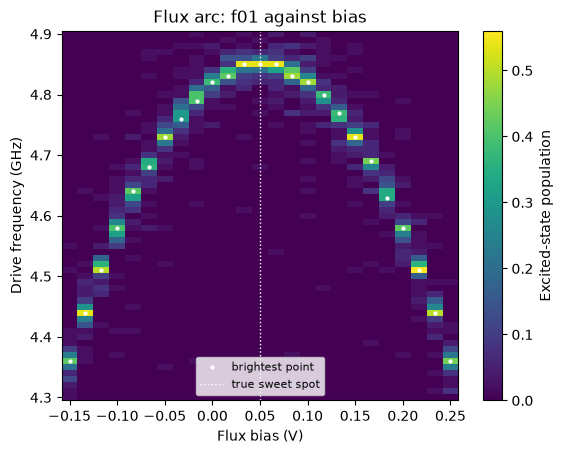

In [21]:
plt.pcolormesh(biases, arc_freqs / 1e9, arc_grid.T, shading="nearest", cmap="viridis")
plt.colorbar(label="Excited-state population")
plt.plot(biases, ridge / 1e9, "w.", markersize=4, label="brightest point")
plt.axvline(DEVICE["flux_offset"], color="white", linestyle=":", linewidth=1, label="true sweet spot")
plt.xlabel("Flux bias (V)")
plt.ylabel("Drive frequency (GHz)")
plt.title("Flux arc: f01 against bias")
plt.legend(fontsize=8, loc="lower center")
plt.show()

### Fitting the arc

The ridge is quantised to the 10 MHz frequency grid, so no single point is better than 10 MHz. The
fit is much better than any of its inputs, because 25 points constrain three parameters and the
arc's symmetry pins the sweet spot far more tightly than the bias step suggests. Fit
$f_{\max}$, $V_0$, and $\Phi_0$ and check all three.

A word on the starting guess. The arc is flat at the top and steep at the edges, so a bad guess for
the period can land the fit a full period away. Start with $V_0$ at the brightest column and
$V_\Phi$ at roughly twice the bias span you scanned.

In [22]:
def arc_model(bias_v, f_max, offset, period):
    """The transmon flux arc: cosine under a square root."""
    return f_max * np.sqrt(np.abs(np.cos(np.pi * (bias_v - offset) / period)))


arc_fit, arc_cov = curve_fit(
    arc_model,
    biases,
    ridge,
    p0=(ridge.max(), float(biases[ridge.argmax()]), 2 * (biases[-1] - biases[0])),
)
f_max_fit, offset_fit, period_fit = arc_fit
arc_sigma = np.sqrt(np.diag(arc_cov))

print(f"f_max  fitted: {f_max_fit / 1e9:.6f} GHz +/- {arc_sigma[0] / 1e6:.3f} MHz")
print(f"f_max  true  : {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"offset fitted: {offset_fit:+.4f} V +/- {arc_sigma[1]:.4f} V")
print(f"offset true  : {DEVICE['flux_offset']:+.4f} V   (bias step was 0.0167 V)")
print(f"period fitted: {period_fit:.4f} V +/- {arc_sigma[2]:.4f} V")
print(f"period true  : {DEVICE['flux_period']:.4f} V")

f_max  fitted: 4.849243 GHz +/- 1.167 MHz
f_max  true  : 4.850000 GHz
offset fitted: +0.0501 V +/- 0.0003 V
offset true  : +0.0500 V   (bias step was 0.0167 V)
period fitted: 0.9989 V +/- 0.0024 V
period true  : 1.0000 V


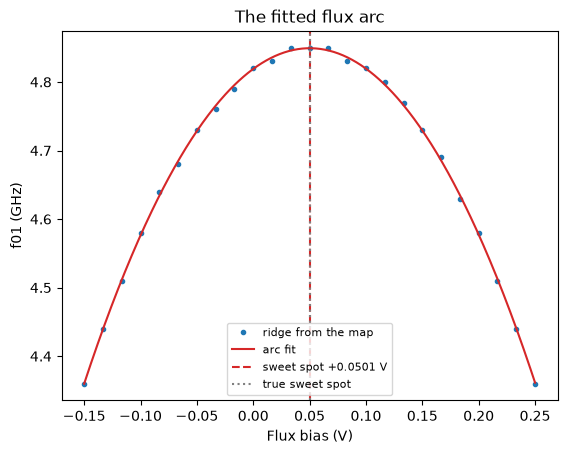

In [23]:
dense_bias = np.linspace(biases[0], biases[-1], 400)

plt.plot(biases, ridge / 1e9, ".", color="tab:blue", label="ridge from the map")
plt.plot(dense_bias, arc_model(dense_bias, *arc_fit) / 1e9, color="tab:red", label="arc fit")
plt.axvline(offset_fit, color="tab:red", linestyle="--", label=f"sweet spot {offset_fit:+.4f} V")
plt.axvline(DEVICE["flux_offset"], color="grey", linestyle=":", label="true sweet spot")
plt.xlabel("Flux bias (V)")
plt.ylabel("f01 (GHz)")
plt.title("The fitted flux arc")
plt.legend(fontsize=8)
plt.show()

### 🧩 Exercise 3.2: park the qubit at a target frequency

The arc is a calibration in both directions. You measured $f_{01}$ against bias; the useful form is
bias against $f_{01}$. Invert the model:

$$V = V_0 + \frac{V_\Phi}{\pi} \arccos\!\left( \left( \frac{f_{\text{target}}}{f_{\max}} \right)^{2} \right)$$

Find the bias that puts `f01` at 4.70 GHz, then grade yourself: feed that bias to `f01_of_bias`,
which is the true device, and report the miss in megahertz.

You have `arc_fit` (as `f_max_fit`, `offset_fit`, `period_fit`), `arc_model`, and `f01_of_bias`.
One thing to think about before you print: `arccos` returns one value, but the arc is symmetric
about the sweet spot, so there are two biases that give any frequency below $f_{\max}$. Which side
you want depends on what else is on the chip.

In [24]:
f_target = 4.70e9
step = (period_fit / np.pi) * np.arccos((f_target / f_max_fit) ** 2)

for side, bias_solution in (("above the sweet spot", offset_fit + step), ("below", offset_fit - step)):
    print(f"{side:>20}: bias {bias_solution:+.4f} V")
    print(f"{'arc model says':>20}: {arc_model(bias_solution, *arc_fit) / 1e9:.6f} GHz")
    print(f"{'true device gives':>20}: {f01_of_bias(bias_solution) / 1e9:.6f} GHz")
    print(f"{'miss':>20}: {(f01_of_bias(bias_solution) - f_target) / 1e6:+.3f} MHz")

print(f"\ntarget was {f_target / 1e9:.3f} GHz; the two solutions are mirrored about the sweet spot.")

above the sweet spot: bias +0.1614 V
      arc model says: 4.700000 GHz
   true device gives: 4.700657 GHz
                miss: +0.657 MHz
               below: bias -0.0611 V
      arc model says: 4.700000 GHz
   true device gives: 4.701446 GHz
                miss: +1.446 MHz

target was 4.700 GHz; the two solutions are mirrored about the sweet spot.


### What that outer loop actually is

Read the flux arc program again and notice what it does not say.

```
average 50:
  for bias in Linspace(start=-0.15, stop=0.25, num=25):
    set_offset q[0].flux bias
    for arc_freq in Linspace(start=4300000000.0, stop=4900000000.0, num=61):
      ...
```

Two `for` loops, written identically. On a real rack they are nothing alike.

The inner loop retunes a microwave source and fires a pulse. That is microseconds per step, and it
belongs inside the sequencer, compiled to instructions that run without the control PC in the loop.

The outer loop writes a DC voltage to a bias source. Those settle in milliseconds, they are often on
a slow serial bus, and on plenty of racks they are a different instrument entirely with no sequencer
in it. That loop has to run **host-side**: the control computer sets the bias, waits, arms the
sequencer, and collects a full inner scan before moving on.

You never said which was which, and you should not have to. Which loop can run in real time is a
property of the rack, not of the experiment. Part 5 is about exactly that: you hand this program to
a platform descriptor, and the validator tells you where each loop lands, warns you when a loop got
demoted to host-side, and offers a rewrite that recovers the real-time averaging you lost.

We will come back to it after the break.

## Recap and what is next

- **Two-tone spectroscopy** found `f01` to well under a linewidth. The new mechanism was
  `fields=(MF.STATE,)`: ask the measurement for classified outcomes, read them with
  `result.get(handle, field=MF.STATE)`, and averaging hands you a population instead of a shot.
- **Rabi in amplitude** gave the pi amplitude. The new mechanism was a `Variable` living inside a
  waveform constructor, so `IQDrag(amplitude=amp, ...)` is one parametric pulse rather than 41
  literal ones.
- Fit for the parameter you want, not for a generic curve. `a_pi` and `f01` came out of the fit with
  their own uncertainties because the models were written in terms of them.
- **The calibrated pulses are objects.** `PI_PULSE` and `X90_PULSE` are `IQDrag` instances with
  numbers in them and they compare by structure. Part 4 wraps the same shape in a fragment so the
  amplitude lives in exactly one place.
- **The calibration seam** is the string alias plus `with_waveforms`. The program says `play "pi"`
  and stays stable across recalibration; the `WaveformLibrary` carries today's numbers in its own
  `.wfl` file.
- **The flux arc** was the first 2D scan whose outer loop steps a slow DC source. QProgram let you
  write it without saying where it runs, which is the question Part 5 answers.

Next: **Part 4, coherence and feedback.** T1, Ramsey, and echo, built out of reusable pulse
fragments, then single-shot readout and active reset with a real conditional on a measured state.